# Loan-Approval-Prediction

In today's fast-paced financial world, loan approval is a critical aspect of banking and lending institutions. Traditionally, loan approvals have been heavily dependent on manual assessments, where loan officers examine credit histories, income reports, and other personal factors to determine whether an applicant is eligible for a loan. While this approach has been effective in certain cases, it can be inefficient, prone to human error, and often results in inconsistent decision-making. This process can also be time-consuming for both the applicants and the institutions, leading to long waiting periods and sometimes missed opportunities.
With the advent of data analytics and machine learning, financial institutions have begun to explore automation for improving loan approval processes. Machine learning models can process vast amounts of data to make informed decisions, providing a more objective, faster, and consistent approach to loan approval. The integration of these advanced technologies is not only expected to streamline workflows but also to enhance the accuracy of predicting the likelihood of loan repayment.
A key challenge, however, lies in developing a predictive system that can balance the complexities of human financial behavior and existing data patterns. The objective of the Loan-Approval-Prediction system is to build such a solution—an automated, reliable, and scalable model that can predict the approval or rejection of loan applications based on several historical and real-time data points.
The ultimate aim of implementing such a system is to minimize the time spent on each loan decision while maintaining high accuracy, reducing biases, and making the process fairer for all applicants. In doing so, lending institutions can improve their operations, provide quicker responses to applicants, and increase overall customer satisfaction.

#### Dataset Link: https://drive.google.com/file/d/1n1I3hEcgN-YKycu174QRVXcqW2xmQk99/view

## Problem Definition

Loan approval prediction poses a unique challenge due to the multifaceted nature of the factors that influence an applicant’s ability to repay a loan. Traditionally, loan officers have relied on a set of criteria—such as credit score, income level, age, and past loan repayment history—when determining the risk associated with lending money to an individual. However, this process often lacks objectivity and is subject to human bias, where subjective interpretations of the data can lead to unfair or inconsistent decisions. Additionally, the sheer volume of loan applications in large financial institutions makes it increasingly difficult for human evaluators to maintain accuracy and efficiency.


The primary problem to address in this case study is the creation of an automated predictive model capable of accurately forecasting whether a given loan application will be approved or rejected. The model should take into account a variety of features that can significantly affect the loan decision, including:


##### Demographic factors: Age, marital status, education level, and employment status, which often influence an applicant's financial stability and future earning potential.

##### Credit-related factors: Credit score, outstanding debts, and the applicant’s credit history, which are indicative of how reliable an individual has been in repaying previous debts.

##### Financial factors: Monthly income, loan amount, loan term, and debt-to-income ratio, which provide insight into an applicant’s ability to manage additional financial commitments.

##### Behavioral and socio-economic factors: Housing situation, type of employment, and other lifestyle-related information that can impact the applicant’s long-term financial behavior.

The traditional approach of loan approval heavily relies on the judgment of loan officers to interpret these factors and make decisions, which can often result in subjective and biased outcomes. The key problem this project seeks to address is automating this decision-making process using machine learning, ensuring that decisions are made based on data-driven insights rather than human judgment alone.

Furthermore, the model must be able to handle missing or incomplete data, as applicants may not always provide a full set of information. It should also account for the dynamic nature of financial conditions, adjusting predictions based on changes in an applicant’s financial standing over time.


##### By automating the loan approval process through machine learning, the institution can achieve several objectives:

##### Increased efficiency: Loan applications can be processed and evaluated much faster than manual methods, reducing waiting times for applicants.

##### Improved accuracy: The model can more accurately predict loan approval outcomes based on data patterns rather than individual biases or errors.

##### Enhanced fairness: The system can ensure that all applicants are evaluated based on the same objective criteria, minimizing the risk of discrimination based on non-financial factors such as gender, age, or ethnicity.

##### Scalability: Financial institutions can handle a much larger volume of loan applications without needing to increase the size of the workforce or the time spent on each application.


By building such a predictive model, the goal is to improve the loan decision-making process, ensure greater consistency and fairness, and contribute to the financial health of both institutions and their clients.

 ## Load Data and Basic Exploration

In [592]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from termcolor import colored
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the CSV file
df = pd.read_csv("C:/Users/Satendra Singh/Downloads/loan_approval_dataset.csv")

df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Basic Overview & Descriptive Stats

In [594]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

print(df[' loan_status'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
None
          

## Data Cleaning & Remove WhiteSpaces

In [596]:
df.columns = df.columns.str.strip()
df['loan_status'] = df['loan_status'].astype(str).str.strip()
df = df[df['loan_status'].isin(['Approved', 'Rejected'])]
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

## Histograms for Numeric Features

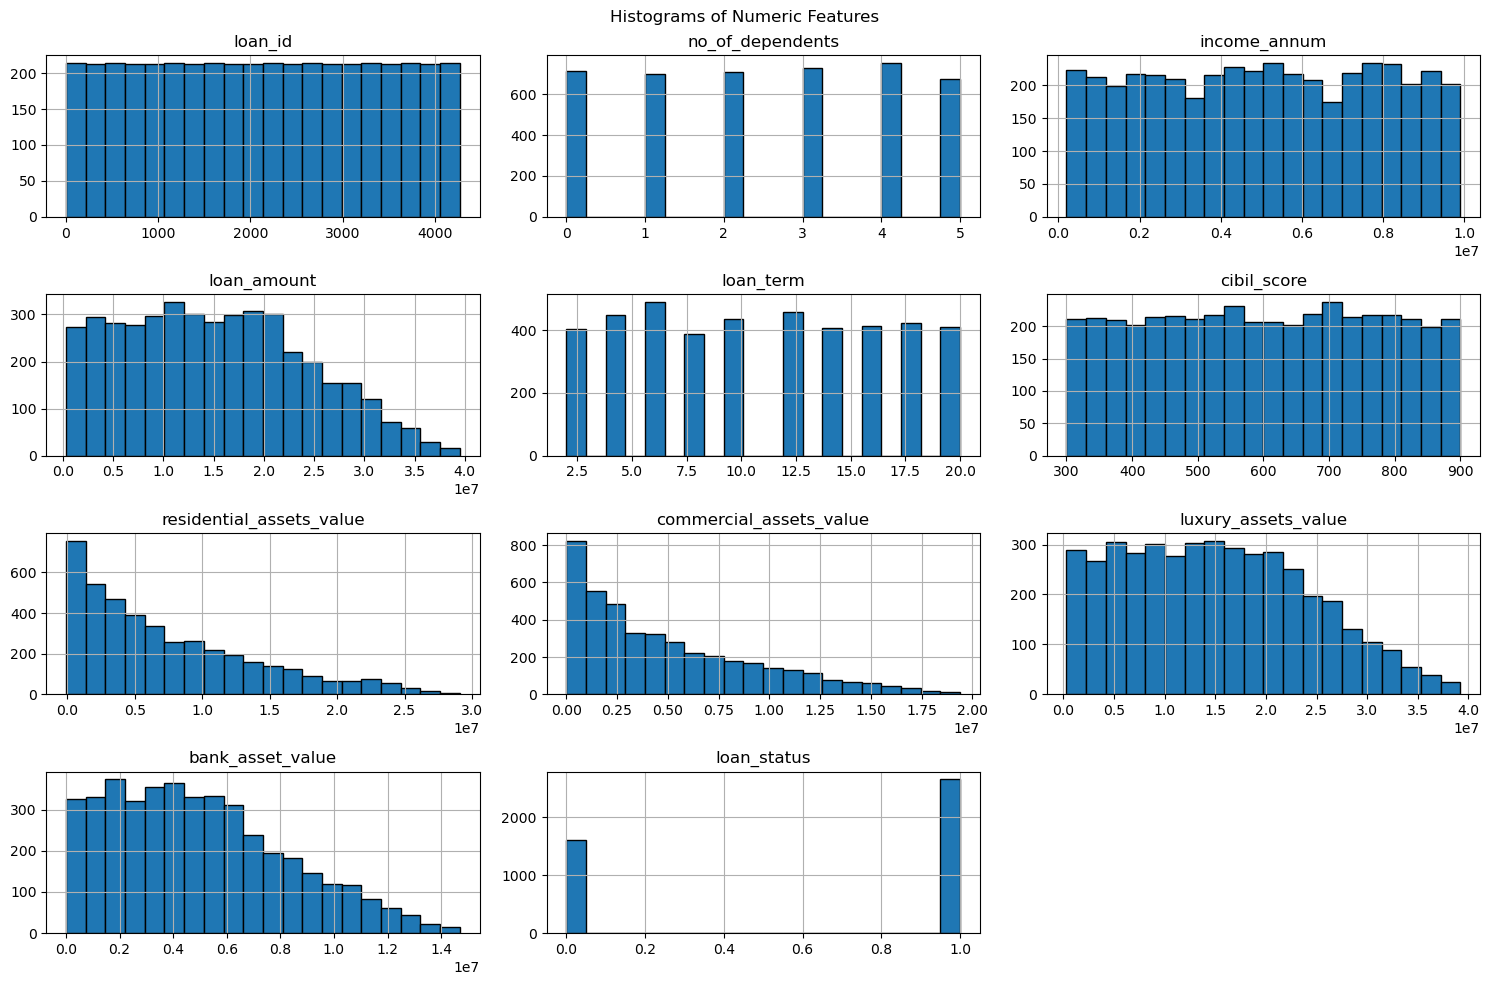

In [598]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(figsize=(15,10), bins=20, edgecolor='black')
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()


## Boxplots to Detect Outliers

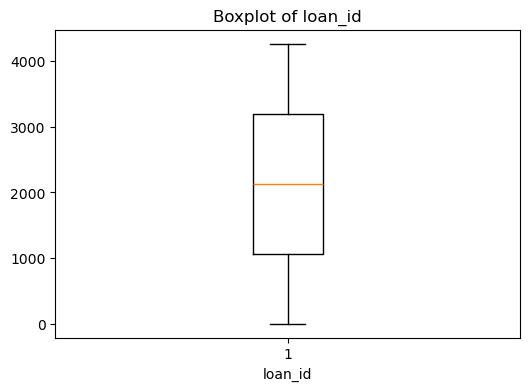

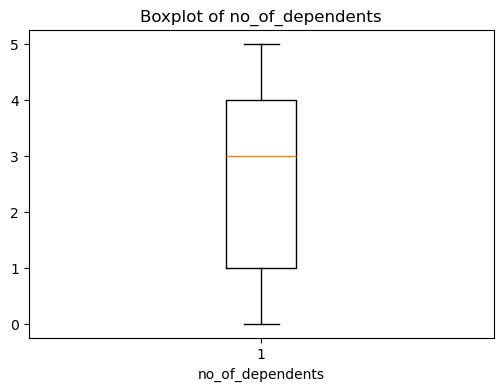

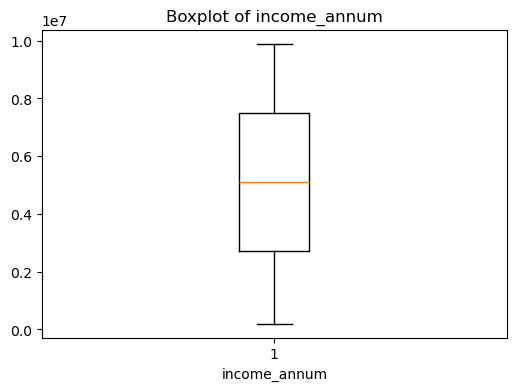

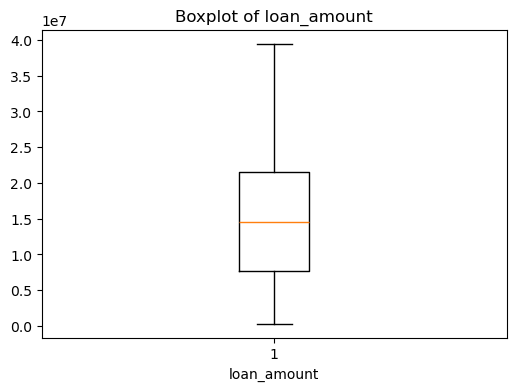

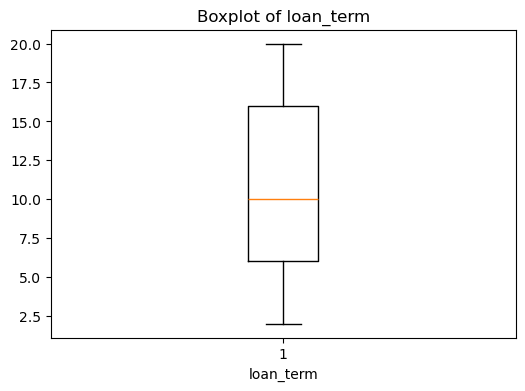

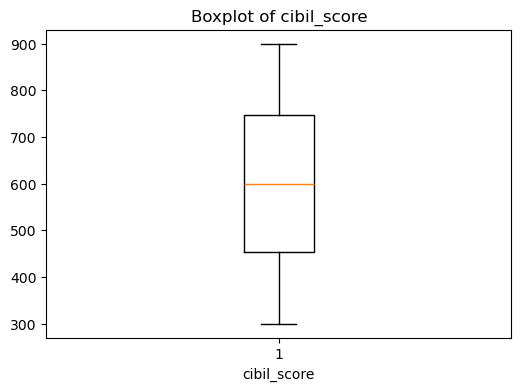

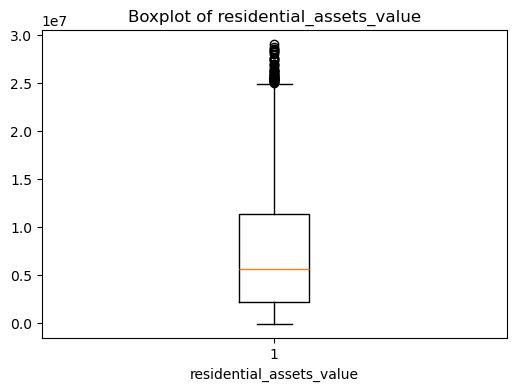

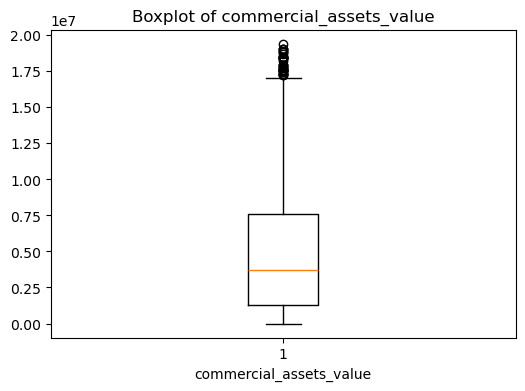

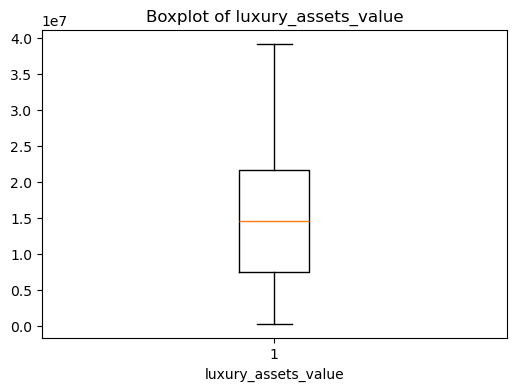

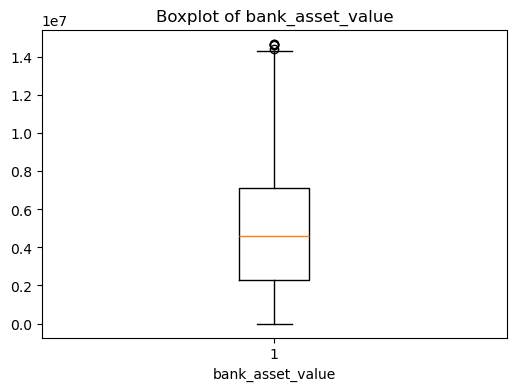

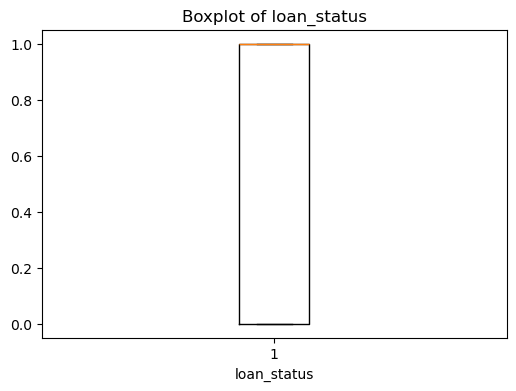

In [600]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()


## Loan Status vs Other Features

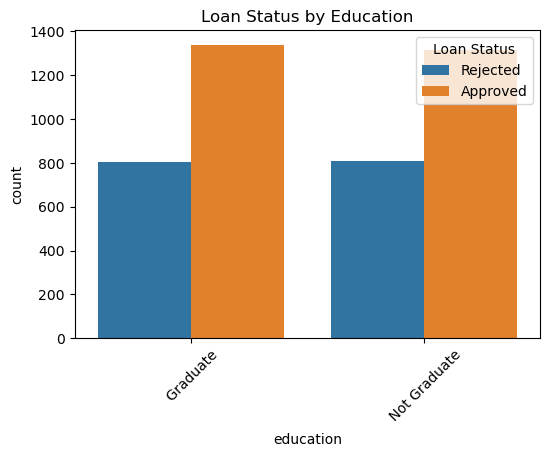

In [602]:
plt.figure(figsize=(6,4))
sns.countplot(x='education', hue='loan_status', data=df)
plt.title('Loan Status by Education')
plt.xticks(rotation=45)
plt.legend(title='Loan Status', labels=['Rejected','Approved'])
plt.show()


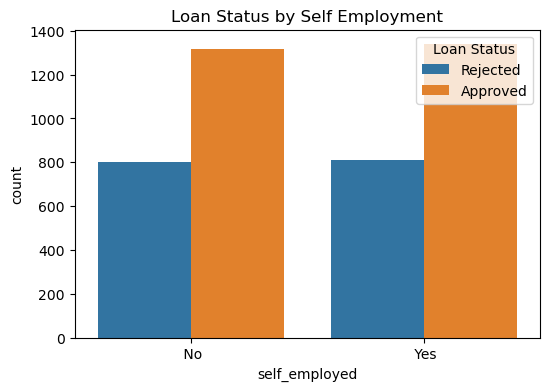

In [603]:
plt.figure(figsize=(6,4))
sns.countplot(x='self_employed', hue='loan_status', data=df)
plt.title('Loan Status by Self Employment')
plt.legend(title='Loan Status', labels=['Rejected','Approved'])
plt.show()


## Correlation Heatmap

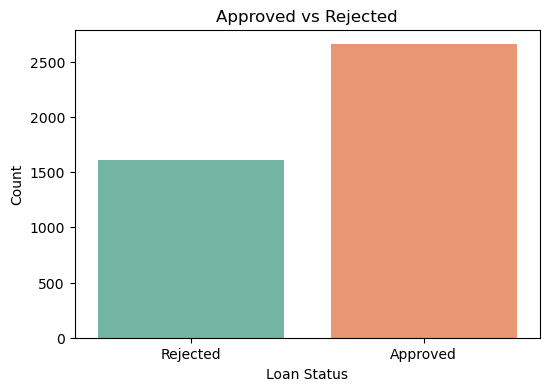

In [605]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='loan_status', palette="Set2")
plt.title("Approved vs Rejected")
plt.xlabel("Loan Status")
plt.ylabel("Count")
ax.set_xticklabels(['Rejected', 'Approved'])
plt.show()


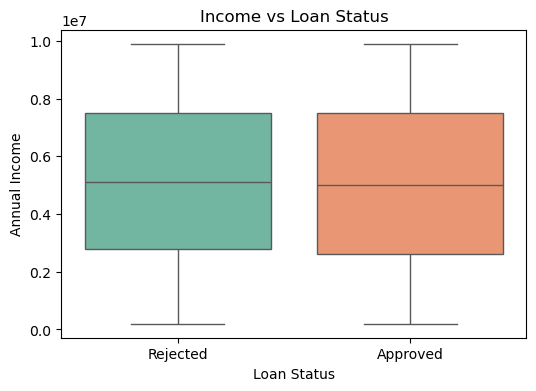

In [606]:
plt.figure(figsize=(6,4))
ax = sns.boxplot(
    x='loan_status',
    y='income_annum',
    data=df,
    palette='Set2'
)
plt.title("Income vs Loan Status")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Annual Income")
# Rename tick labels
ax.set_xticklabels(['Rejected', 'Approved'])
plt.show()


## Data Preprocessing

In [608]:
df_processed = df.copy()

df_processed['education'] = df_processed['education'].astype(str).str.strip()
df_processed['self_employed'] = df_processed['self_employed'].astype(str).str.strip()

le_edu = LabelEncoder()
df_processed['education_encoded'] = le_edu.fit_transform(df_processed['education'])

le_self = LabelEncoder()
df_processed['self_employed_encoded'] = le_self.fit_transform(df_processed['self_employed'])

df_processed['log_income'] = np.log(df_processed['income_annum'].replace(0, np.nan))

df_processed['log_income'] = df_processed['log_income'].fillna(df_processed['log_income'].median())
df_processed['loan_amount'] = df_processed['loan_amount'].fillna(df_processed['loan_amount'].median())
df_processed['loan_term'] = df_processed['loan_term'].fillna(df_processed['loan_term'].median())

df_processed['education_encoded'] = df_processed['education_encoded'].fillna(df_processed['education_encoded'].mode()[0])
df_processed['self_employed_encoded'] = df_processed['self_employed_encoded'].fillna(df_processed['self_employed_encoded'].mode()[0])

## Train-Test Split

In [610]:
print(df_processed.columns)


Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status',
       'education_encoded', 'self_employed_encoded', 'log_income'],
      dtype='object')


In [611]:
X = df_processed.drop(['loan_id', 'loan_status'], axis=1)
y = df_processed['loan_status']

In [612]:
X = df_processed[[
    'no_of_dependents',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value',
    'education_encoded',
    'self_employed_encoded',
    'log_income'
]]
y = df_processed['loan_status']

In [613]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [614]:
print(X_train.shape)

(3415, 11)


## Model Building (Random Forest) & Evaluation

In [616]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Random Forest Accuracy: 0.9812646370023419
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



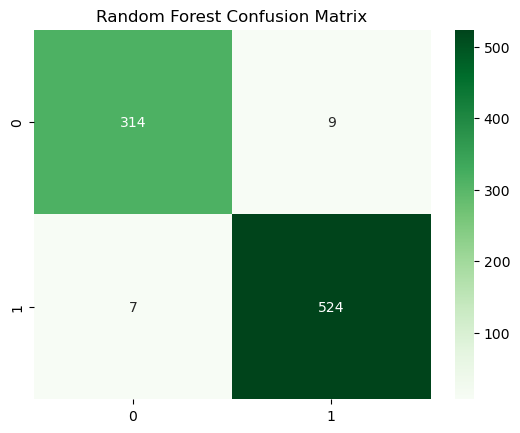

In [617]:
# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

# Classification Report
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

## ROC Curve for Random Forest

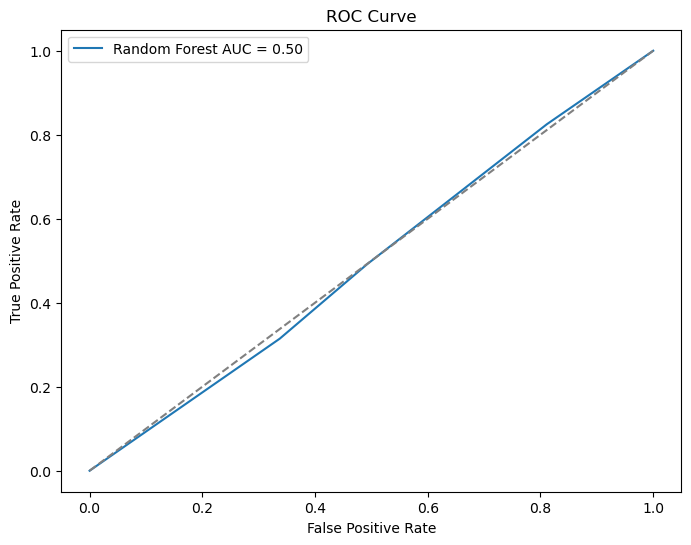

In [619]:
y_prob_rf = rf_clf.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Loan Approval Simulation

In [621]:
manual_input = {
    'no_of_dependents': 2,
    'loan_amount': 300000,
    'loan_term': 15,
    'cibil_score': 700,
    'residential_assets_value': 1500000,
    'commercial_assets_value': 500000,
    'luxury_assets_value': 200000,
    'bank_asset_value': 100000,
    'education_encoded': 1,
    'self_employed_encoded': 0,
    'log_income': np.log(800000)
}

manual_df = pd.DataFrame([manual_input])

prediction = rf_clf.predict(manual_df)[0]
probability = rf_clf.predict_proba(manual_df)[0][1]

print("Prediction (1=Approved, 0=Rejected):", prediction)
print(f"Approval Probability: {probability:.2%}")

Prediction (1=Approved, 0=Rejected): 1
Approval Probability: 94.00%


# Real-Time Loan Approval Prediction Using User Input


=== Loan Approval Prediction ===


No. of Dependents (e.g. 0, 1, 2):  2
Education (Graduate=1, Not Graduate=0):  1
Self-Employed (Yes=1, No=0):  1
Annual Income (e.g. 800000):  650000
Loan Amount Required (e.g. 500000):  2000000
Loan Term in Years (e.g. 10):  15
CIBIL Score (e.g. 750):  742
Residential Assets Value (e.g. 200000):  0
Commercial Assets Value (e.g. 100000):  0
Luxury Assets Value (e.g. 50000):  0
Bank Asset Value (e.g. 250000):  150000



Loan Prediction Result:
Loan Approved
Approval Probability: 67.00%


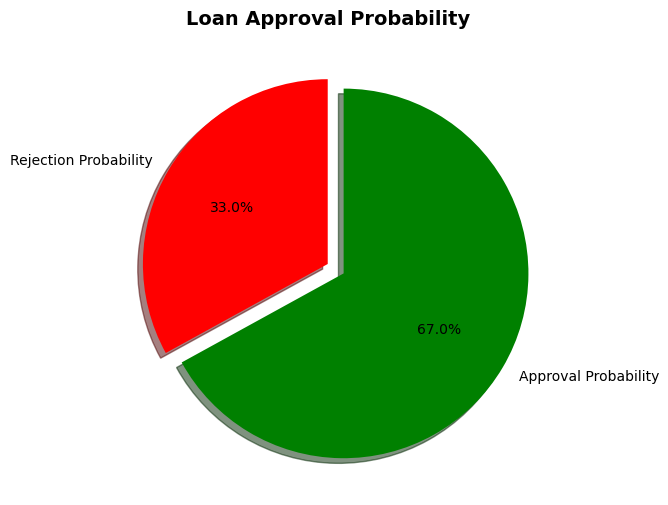

In [623]:
print(colored("=== Loan Approval Prediction ===", "cyan", attrs=["bold"]))
no_of_dependents = int(input("No. of Dependents (e.g. 0, 1, 2): "))
education_encoded = int(input("Education (Graduate=1, Not Graduate=0): "))
self_employed_encoded = int(input("Self-Employed (Yes=1, No=0): "))
income_annum = int(input("Annual Income (e.g. 800000): "))
loan_amount = int(input("Loan Amount Required (e.g. 500000): "))
loan_term = int(input("Loan Term in Years (e.g. 10): "))
cibil_score = int(input("CIBIL Score (e.g. 750): "))
residential_assets_value = int(input("Residential Assets Value (e.g. 200000): "))
commercial_assets_value = int(input("Commercial Assets Value (e.g. 100000): "))
luxury_assets_value = int(input("Luxury Assets Value (e.g. 50000): "))
bank_asset_value = int(input("Bank Asset Value (e.g. 250000): "))

log_income = np.log(income_annum)

new_data = np.array([[
    no_of_dependents,
    loan_amount,
    loan_term,
    cibil_score,
    residential_assets_value,
    commercial_assets_value,
    luxury_assets_value,
    bank_asset_value,
    education_encoded,
    self_employed_encoded,
    log_income
]])

prediction = rf_clf.predict(new_data)
probability = rf_clf.predict_proba(new_data)[0][1]

print("\n" + "="*40)
print(colored("Loan Prediction Result:", "yellow", attrs=["bold"]))

if prediction[0] == 1:
    print(colored("Loan Approved", "green", attrs=["bold"]))
else:
    print(colored("Loan Rejected", "red", attrs=["bold"]))

print(colored(f"Approval Probability: {probability:.2%}", "cyan", attrs=["bold"]))
print("="*40)

plt.figure(figsize=(6,6))
colors = ["red", "green"]
labels = ["Rejection Probability", "Approval Probability"]
sizes = [1 - probability, probability]
explode = (0, 0.1)

plt.pie(
    sizes, 
    labels=labels, 
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True
)

plt.title("Loan Approval Probability", fontsize=14, fontweight="bold")
plt.show()